## From ROOT

In [7]:
import ROOT
ROOT.gROOT.SetBatch(True)
ROOT.gSystem.Load("/Users/IvanTang/hep/E320Prototype_preprocessing/build/libDetEventClusteredDict.dylib")

f = ROOT.TFile.Open("/Users/IvanTang/hep/data_Run502/processed/data_Run502.root")
t = f.Get("MyTree")

event = ROOT.E320Io.DetectorEvent()
t.SetBranchAddress("event", event)

nentries = t.GetEntries()
print("entries =", nentries)

max_events = 5

for ievt in range(min(nentries, max_events)):
    t.GetEntry(ievt)
    print(f"\n=== Event {ievt} ===")

    # st_ev_buffer 看起来是一个容器
    n_staves = len(event.st_ev_buffer)
    print("n_staves =", n_staves)

    for istave, stave in enumerate(event.st_ev_buffer):
        print(f"  stave {istave}, stave_id = {stave.stave_id}")

        # ch_ev_buffer 是 vector<E320Io::ChipEvent>
        n_chips = len(stave.ch_ev_buffer)
        print(f"    n_chips = {n_chips}")

        for ichip, chip in enumerate(stave.ch_ev_buffer):
            nhits = len(chip.hits)
            if nhits == 0:
                continue

            print(f"    chip {ichip}, nhits = {nhits}")

            for ihit, hit in enumerate(chip.hits[:10]):  # 只打印前10个hit，防止太长
                print(
                    f"      hit {ihit}: "
                    f"xCenter={hit.xCenter}, "
                    f"yCenter={hit.yCenter}, "
                    f"dx={hit.dx}, dy={hit.dy}, "
                    f"cl_size={hit.cl_size}"
                )

entries = 1770

=== Event 0 ===
n_staves = 1
  stave 0, stave_id = 0
    n_chips = 5
    chip 0, nhits = 595
      hit 0: xCenter=1023.0, yCenter=372.0, dx=1, dy=1, cl_size=1
      hit 1: xCenter=1022.5, yCenter=193.0, dx=2, dy=1, cl_size=2
      hit 2: xCenter=1019.0, yCenter=173.0, dx=1, dy=1, cl_size=1
      hit 3: xCenter=1015.5, yCenter=179.0, dx=2, dy=1, cl_size=2
      hit 4: xCenter=1013.5, yCenter=181.5, dx=2, dy=2, cl_size=4
      hit 5: xCenter=1012.0, yCenter=331.0, dx=1, dy=1, cl_size=1
      hit 6: xCenter=1013.0, yCenter=280.5, dx=1, dy=2, cl_size=2
      hit 7: xCenter=1012.5, yCenter=5.5, dx=2, dy=2, cl_size=4
      hit 8: xCenter=1008.5, yCenter=492.0, dx=2, dy=1, cl_size=2
      hit 9: xCenter=1003.6666666666666, yCenter=163.33333333333334, dx=2, dy=2, cl_size=3
    chip 1, nhits = 641
      hit 0: xCenter=1013.6666666666666, yCenter=509.6666666666667, dx=2, dy=2, cl_size=3
      hit 1: xCenter=1013.5, yCenter=37.5, dx=2, dy=2, cl_size=4
      hit 2: xCenter=1010.0, 

total hits = 5360276


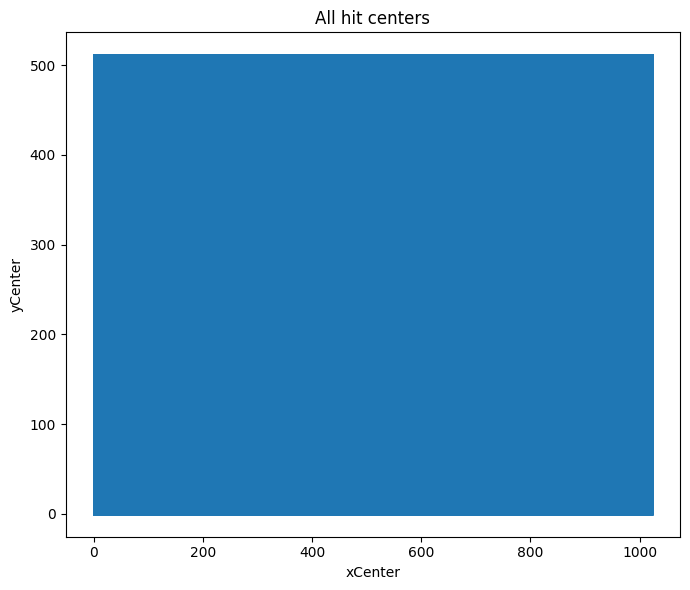

In [9]:
import ROOT
import matplotlib.pyplot as plt

f = ROOT.TFile.Open("/Users/IvanTang/hep/data_Run502/processed/data_Run502.root")
t = f.Get("MyTree")

x_all = []
y_all = []

for ievt in range(t.GetEntries()):
    t.GetEntry(ievt)
    event = t.event

    for istave in range(event.st_ev_buffer.size()):
        stave = event.st_ev_buffer[istave]

        for ichip in range(stave.ch_ev_buffer.size()):
            chip = stave.ch_ev_buffer[ichip]

            for ihit in range(chip.hits.size()):
                hit = chip.hits[ihit]
                x_all.append(float(hit.xCenter))
                y_all.append(float(hit.yCenter))

print("total hits =", len(x_all))

plt.figure(figsize=(7, 6))
plt.scatter(x_all, y_all, s=1)
plt.xlabel("xCenter")
plt.ylabel("yCenter")
plt.title("All hit centers")
plt.tight_layout()
plt.show()

In [ ]:
import ROOT

f = ROOT.TFile.Open("/Users/IvanTang/hep/data_Run502/processed/data_Run502.root")
t = f.Get("MyTree")

h_x = ROOT.TH1F("h_x", "xCenter; xCenter; Counts", 100, 0, 1024)

for ievt in range(t.GetEntries()):
    t.GetEntry(ievt)
    event = t.event

    for istave in range(event.st_ev_buffer.size()):
        stave = event.st_ev_buffer[istave]
        for ichip in range(stave.ch_ev_buffer.size()):
            chip = stave.ch_ev_buffer[ichip]
            for ihit in range(chip.hits.size()):
                hit = chip.hits[ihit]
                h_x.Fill(float(hit.xCenter))

c1 = ROOT.TCanvas("c1", "xCenter hist", 800, 600)
h_x.Draw()
c1.SaveAs("xCenter_hist.png")

Info in <TCanvas::Print>: png file xCenter_hist.png has been created


: 

In [ ]:
import ROOT

f = ROOT.TFile.Open("/Users/IvanTang/hep/data_Run502/processed/data_Run502.root")
t = f.Get("MyTree")

h_y = ROOT.TH1F("h_y", "yCenter; yCenter; Counts", 100, 0, 512)

for ievt in range(t.GetEntries()):
    t.GetEntry(ievt)
    event = t.event

    for istave in range(event.st_ev_buffer.size()):
        stave = event.st_ev_buffer[istave]
        for ichip in range(stave.ch_ev_buffer.size()):
            chip = stave.ch_ev_buffer[ichip]
            for ihit in range(chip.hits.size()):
                hit = chip.hits[ihit]
                h_y.Fill(float(hit.yCenter))

c1 = ROOT.TCanvas("c1", "yCenter hist", 800, 600)
h_y.Draw()
c1.SaveAs("yCenter_hist.png")

In [ ]:
import ROOT

f = ROOT.TFile.Open("/Users/IvanTang/hep/data_Run502/processed/data_Run502.root")
t = f.Get("MyTree")

h_cl_size = ROOT.TH1F("h_cl_size", "cl_size; cl_size; Size", 100, 0, 5)

for ievt in range(t.GetEntries()):
    t.GetEntry(ievt)
    event = t.event

    for istave in range(event.st_ev_buffer.size()):
        stave = event.st_ev_buffer[istave]
        for ichip in range(stave.ch_ev_buffer.size()):
            chip = stave.ch_ev_buffer[ichip]
            for ihit in range(chip.hits.size()):
                hit = chip.hits[ihit]
                h_cl_size.Fill(float(hit.cl_size))

c1 = ROOT.TCanvas("c1", "cl_size hist", 800, 600)
h_cl_size.Draw()
c1.SaveAs("clsize_hist.png")

Info in <TCanvas::Print>: png file clsize_hist.png has been created


## From parquet

In [1]:
import polars as pl
df = pl.read_parquet('/Users/IvanTang/hep/data_Run502/processed/hit_level.parquet')
df.head()

event_id,entry,det_type,stave_id,sensor_id,hit_x,hit_y,size_x,size_y,size,mean_x,mean_y,stddev_x,stddev_y
i64,i64,str,i64,i64,f64,f64,i64,i64,i64,f64,f64,f64,f64
0,0,"""pixel""",0,6,1023.0,372.0,1,1,1,-1.0,-1.0,-1.0,-1.0
0,0,"""pixel""",0,6,1022.5,193.0,2,1,2,-1.0,-1.0,-1.0,-1.0
0,0,"""pixel""",0,6,1019.0,173.0,1,1,1,-1.0,-1.0,-1.0,-1.0
0,0,"""pixel""",0,6,1015.5,179.0,2,1,2,-1.0,-1.0,-1.0,-1.0
0,0,"""pixel""",0,6,1013.5,181.5,2,2,4,-1.0,-1.0,-1.0,-1.0


In [2]:
df.select("det_type").unique()

det_type
str
"""pixel"""
"""bpm"""


In [3]:
df_clean = df.filter(pl.col('det_type') == 'pixel')
print(df_clean.select("sensor_id").unique())
print(df_clean)

shape: (5, 1)
┌───────────┐
│ sensor_id │
│ ---       │
│ i64       │
╞═══════════╡
│ 0         │
│ 6         │
│ 4         │
│ 8         │
│ 2         │
└───────────┘
shape: (5_360_276, 14)
┌──────────┬───────┬──────────┬──────────┬───┬────────┬────────┬──────────┬──────────┐
│ event_id ┆ entry ┆ det_type ┆ stave_id ┆ … ┆ mean_x ┆ mean_y ┆ stddev_x ┆ stddev_y │
│ ---      ┆ ---   ┆ ---      ┆ ---      ┆   ┆ ---    ┆ ---    ┆ ---      ┆ ---      │
│ i64      ┆ i64   ┆ str      ┆ i64      ┆   ┆ f64    ┆ f64    ┆ f64      ┆ f64      │
╞══════════╪═══════╪══════════╪══════════╪═══╪════════╪════════╪══════════╪══════════╡
│ 0        ┆ 0     ┆ pixel    ┆ 0        ┆ … ┆ -1.0   ┆ -1.0   ┆ -1.0     ┆ -1.0     │
│ 0        ┆ 0     ┆ pixel    ┆ 0        ┆ … ┆ -1.0   ┆ -1.0   ┆ -1.0     ┆ -1.0     │
│ 0        ┆ 0     ┆ pixel    ┆ 0        ┆ … ┆ -1.0   ┆ -1.0   ┆ -1.0     ┆ -1.0     │
│ 0        ┆ 0     ┆ pixel    ┆ 0        ┆ … ┆ -1.0   ┆ -1.0   ┆ -1.0     ┆ -1.0     │
│ 0        ┆ 0     ┆ pixel

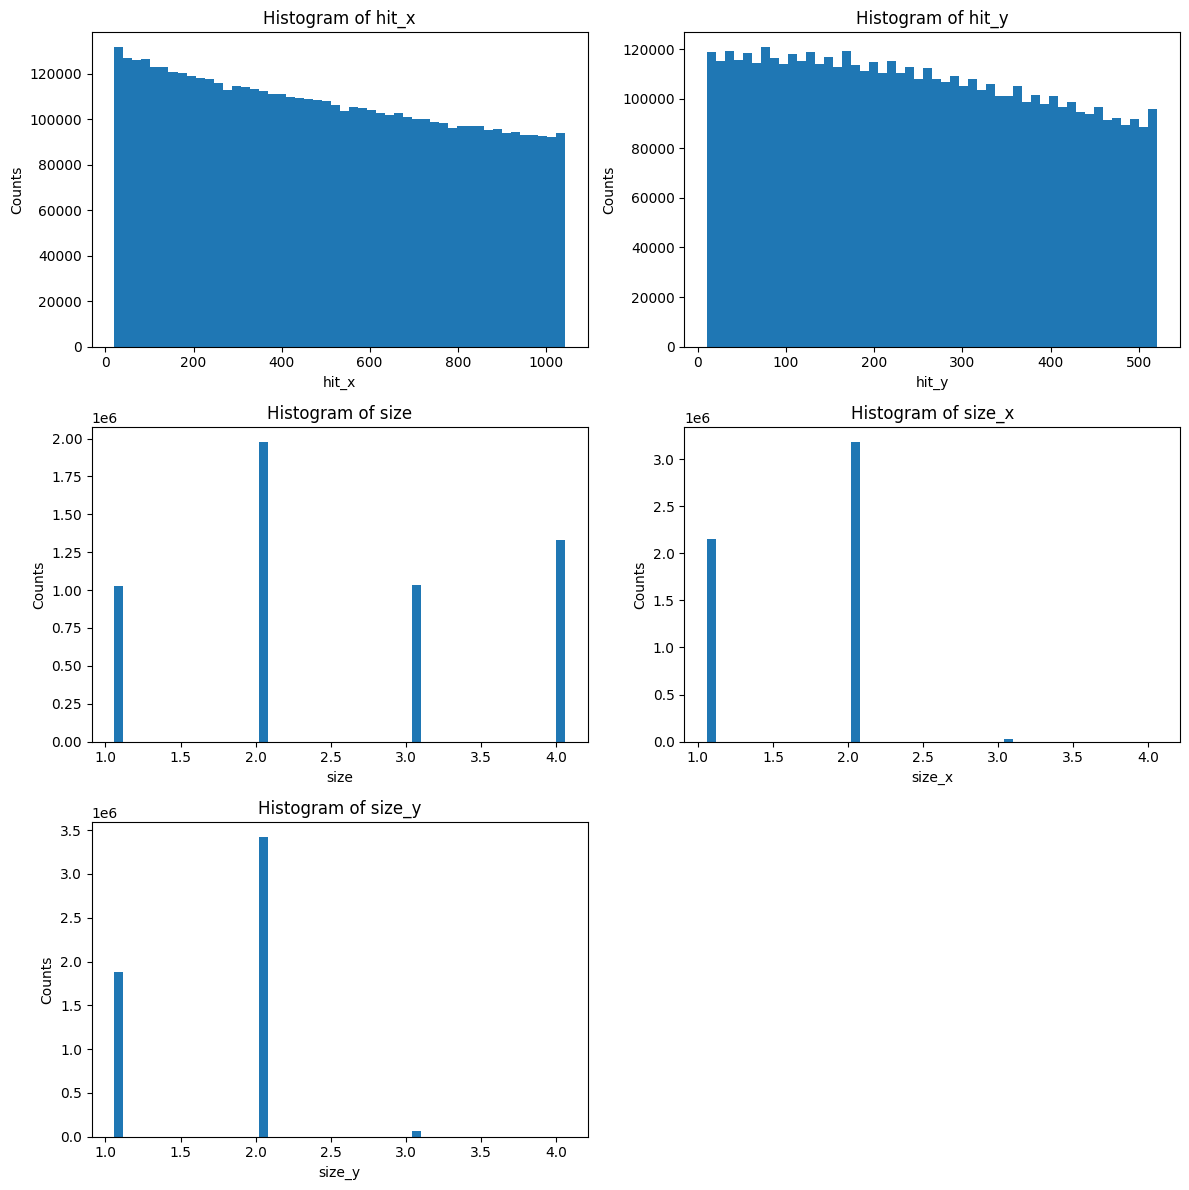

In [5]:
import matplotlib.pyplot as plt
# 绘制多列直方图
columns_to_plot = ["hit_x", "hit_y", "size", "size_x", "size_y"]  # 要绘制的列列表

n = len(columns_to_plot)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    ax = axes[i]
    if col not in df_clean.columns:
        ax.text(0.5, 0.5, f"{col} not found", ha="center", va="center")
        ax.set_axis_off()
        continue

    hist_df = df_clean.select(pl.col(col)).to_series().hist(bin_count=50)
    x = hist_df["breakpoint"].to_numpy()
    y = hist_df["count"].to_numpy()
    width = x[1] - x[0] if len(x) > 1 else 1

    ax.bar(x, y, width=width, align="edge")
    ax.set_xlabel(col)
    ax.set_ylabel("Counts")
    ax.set_title(f"Histogram of {col}")

# 隐藏多余子图
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [6]:
df_clean

event_id,entry,det_type,stave_id,sensor_id,hit_x,hit_y,size_x,size_y,size,mean_x,mean_y,stddev_x,stddev_y
i64,i64,str,i64,i64,f64,f64,i64,i64,i64,f64,f64,f64,f64
0,0,"""pixel""",0,6,1023.0,372.0,1,1,1,-1.0,-1.0,-1.0,-1.0
0,0,"""pixel""",0,6,1022.5,193.0,2,1,2,-1.0,-1.0,-1.0,-1.0
0,0,"""pixel""",0,6,1019.0,173.0,1,1,1,-1.0,-1.0,-1.0,-1.0
0,0,"""pixel""",0,6,1015.5,179.0,2,1,2,-1.0,-1.0,-1.0,-1.0
0,0,"""pixel""",0,6,1013.5,181.5,2,2,4,-1.0,-1.0,-1.0,-1.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…
1769,1769,"""pixel""",0,6,2.0,269.0,1,1,1,-1.0,-1.0,-1.0,-1.0
1769,1769,"""pixel""",0,6,19.0,350.5,1,2,2,-1.0,-1.0,-1.0,-1.0
1769,1769,"""pixel""",0,6,881.666667,374.666667,2,2,3,-1.0,-1.0,-1.0,-1.0


In [ ]:
sizes = [1, 2, 3, 4, 5]
size_xs = [1, 2, 3, 4, 5]
size_ys = [1, 2, 3, 4, 5]

for size in sizes:
    n = df_clean.filter(pl.col("size") == size).height
    print(f"size: {size}, num of size: {n}")

for size_x in size_xs:
    n = df_clean.filter(pl.col("size_x") == size_x).height
    print(f"size_x: {size_x}, num of size_x: {n}")

for size_y in size_ys:
    n = df_clean.filter(pl.col("size_y") == size_y).height
    print(f"size_y: {size_y}, num of size_y: {n}")

size: 1, num of size: 1024416
size: 2, num of size: 1975504
size: 3, num of size: 1032871
size: 4, num of size: 1327485
size: 5, num of size: 0
size_x: 1, num of size_x: 2148147
size_x: 2, num of size_x: 3180951
size_x: 3, num of size_x: 30964
size_x: 4, num of size_x: 214
size_x: 5, num of size_x: 0
size_y: 1, num of size_y: 1882453
size_y: 2, num of size_y: 3419185
size_y: 3, num of size_y: 58245
size_y: 4, num of size_y: 393
size_y: 5, num of size_y: 0
